Import Libraries

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

Load Dataset

In [47]:
df = pd.read_csv(r"Superstore_Sales.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Data Cleaning

In [48]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

df.drop_duplicates(inplace=True)

df = df.dropna()

Feature Engineering

In [49]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.month_name()

Key Performance Indicators (KPIs)

In [50]:
total_revenue = df['Sales'].sum()

total_orders = df['Order ID'].nunique()

avg_order_value = df['Sales'].mean()

total_quantity = df['Quantity'].sum()

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Average Order Value:", avg_order_value)
print("Total Quantity Sold:", total_quantity)

Total Revenue: 2297200.8603
Total Orders: 5009
Average Order Value: 229.85800083049827
Total Quantity Sold: 37873


Monthly Revenue Trend

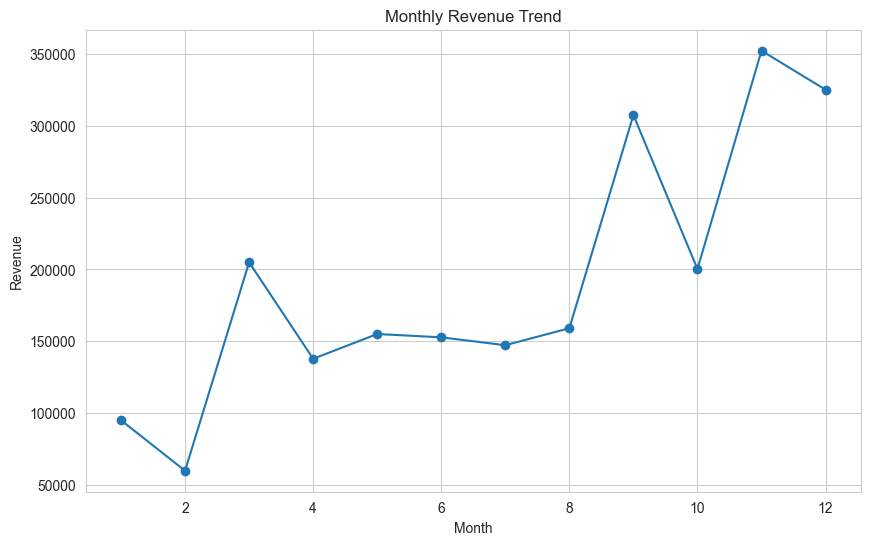

In [51]:
monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(10,6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.savefig("images/revenue_trend.png")

plt.show()

Monthly Sales Trend

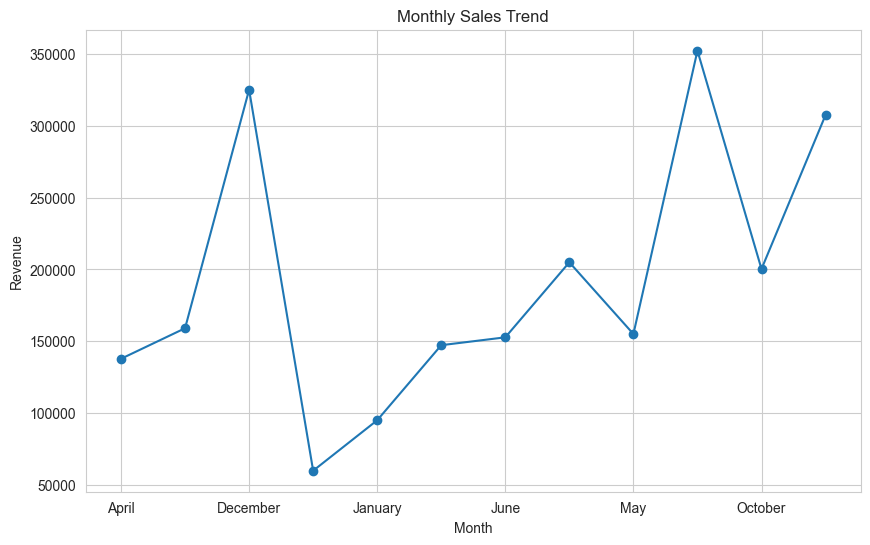

In [52]:
monthly_sales = df.groupby('Month_Name')['Sales'].sum()

plt.figure(figsize=(10,6))
monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

Top 10 Products by Revenue

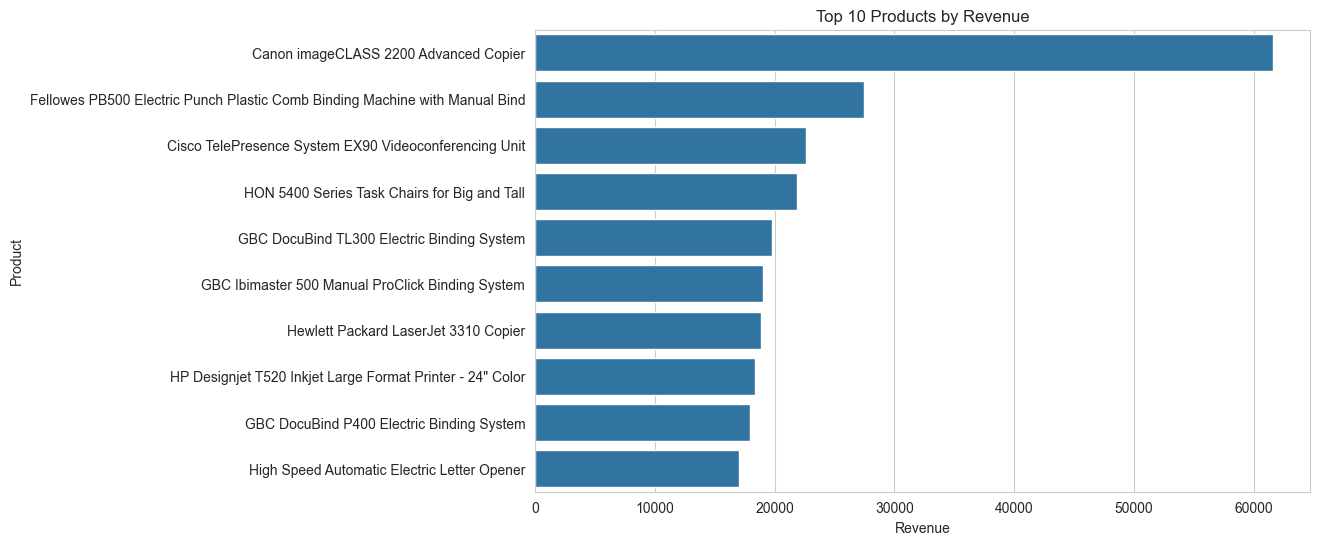

In [53]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_products.values, y=top_products.index)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.savefig("images/top_products.png")

plt.show()

Sales by Region

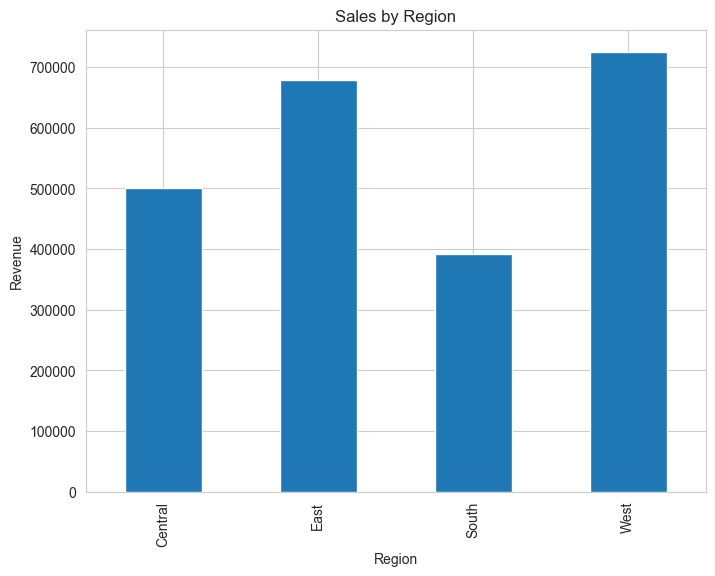

In [54]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(8,6))

region_sales.plot(kind='bar')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")

plt.savefig("images/region_sales.png")

plt.show()

Category Sales Analysis

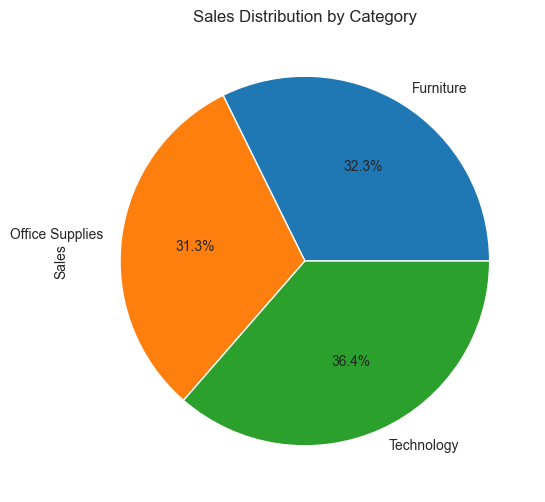

In [55]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,6))

category_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title("Sales Distribution by Category")

plt.savefig("images/category_sales.png")

plt.show()

Sub-Category Analysis

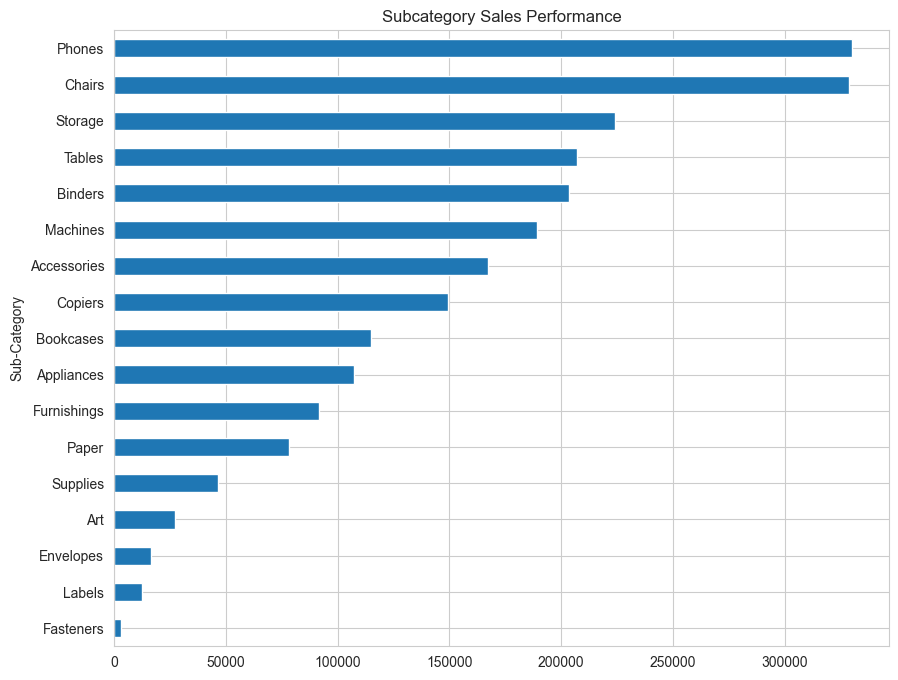

In [56]:
subcategory_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values()

plt.figure(figsize=(10,8))

subcategory_sales.plot(kind='barh')

plt.title("Subcategory Sales Performance")

plt.show()

Profit vs Sales Analysis

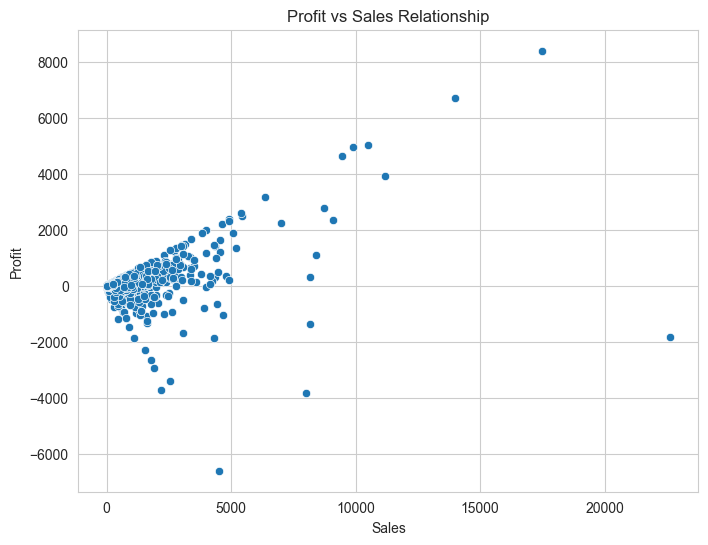

In [57]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x="Sales", y="Profit")

plt.title("Profit vs Sales Relationship")

plt.show()

Correlation Heatmap

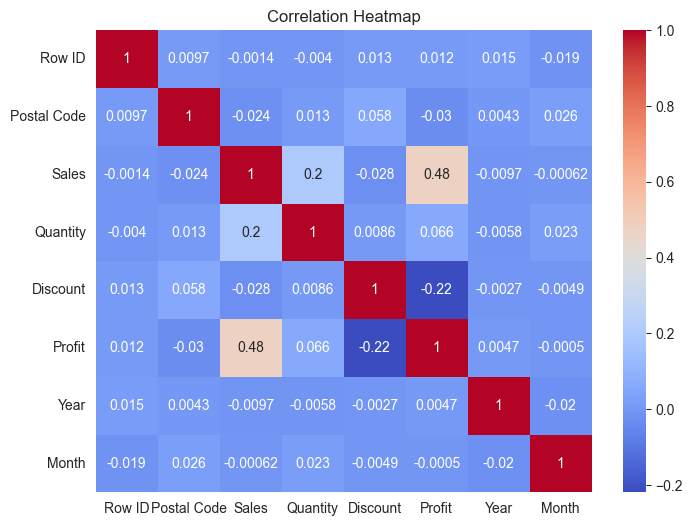

In [58]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig("images/correlation_heatmap.png")

plt.show()

Export KPI Summary

In [59]:
summary = pd.DataFrame({
    "Metric":[
        "Total Revenue",
        "Total Orders",
        "Average Order Value",
        "Total Quantity Sold"
    ],
    
    "Value":[
        total_revenue,
        total_orders,
        avg_order_value,
        total_quantity
    ]
})

summary.to_csv("reports/sales_kpi_summary.csv", index=False)